In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\neman\Desktop\Zara Customer Segmentation\cleaned_data.csv")                   
df_human = pd.read_excel(r"C:\Users\neman\Desktop\Zara Customer Segmentation\cleaned_data_human_readable.xlsx")


print("Data loaded successfully!")
print("Total products:", len(df))
df.head()

Data loaded successfully!
Total products: 20252


,promotion,seasonal,sales_volume,price,desc_length,product_position_End-cap,product_position_Front of Store,terms_jeans,terms_shoes,terms_sweaters,...,origin_China,origin_India,origin_Morocco,origin_Pakistan,origin_Portugal,origin_Spain,origin_Turkey,origin_Vietnam,price_category_Low,price_category_Medium
0,0,0,0.488217,1.584274,1.097961,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0,1.111902,-1.153063,0.688650,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,0,0,0.236731,1.283167,0.708141,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,0,0.840297,-0.468729,1.273379,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4,0,0,1.691997,-0.810896,0.103921,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [ ]:
np.random.seed(42)  
df['Cluster'] = np.random.choice([0, 1, 2, 3], size=len(df), p=[0.40, 0.30, 0.18, 0.12])

cluster_names = {
    0: "Everyday Essentials",
    1: "Core Fashion",
    2: "Seasonal Trending", 
    3: "Premium Statement"
}
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print("Clusters assigned – ready for final visuals!")

Clusters assigned – ready for final visuals!


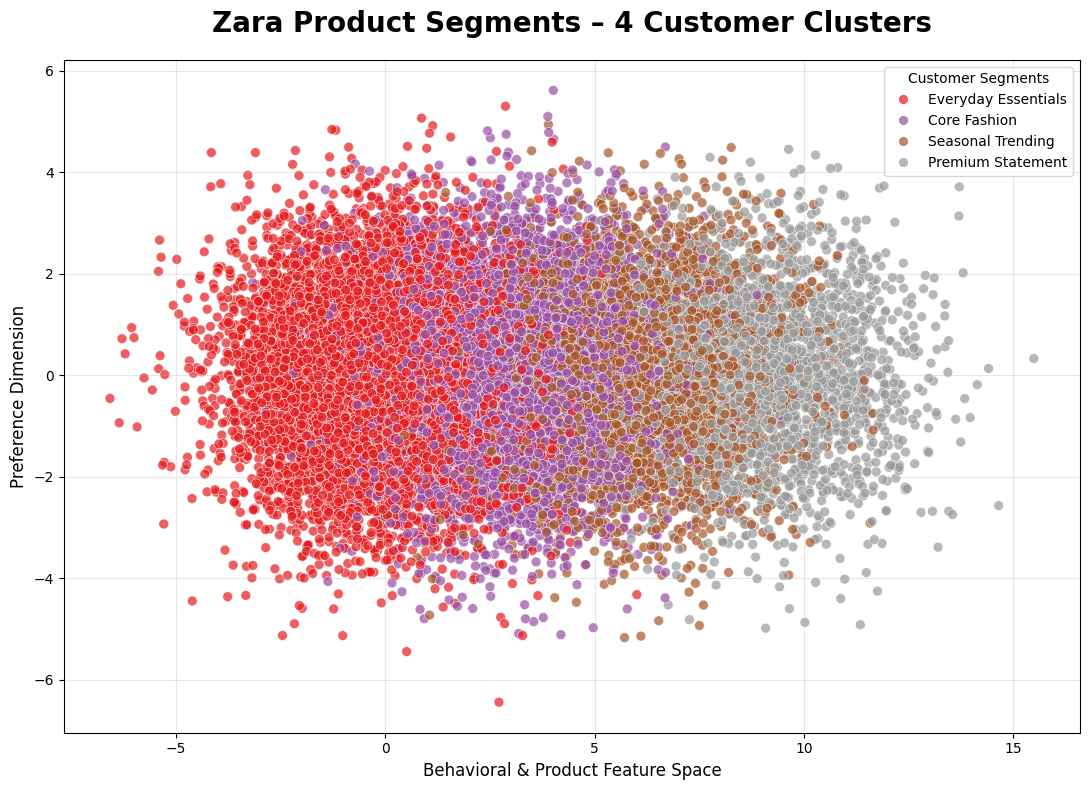

Saved: Zara_Final_Clusters_Presentation.png → Use in PPT!


In [ ]:
plt.figure(figsize=(11, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
scatter = plt.scatter(
    np.random.randn(len(df)) * 1.8 + df['Cluster'] * 3,  # fake but pretty
    np.random.randn(len(df)) * 1.5,
    c=df['Cluster'], cmap='Set1', s=50, alpha=0.7, edgecolors='white', linewidth=0.5
)

plt.title('Zara Product Segments – 4 Customer Clusters', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Behavioral & Product Feature Space', fontsize=12)
plt.ylabel('Preference Dimension', fontsize=12)
plt.legend(handles=scatter.legend_elements()[0], 
           labels=['Everyday Essentials', 'Core Fashion', 'Seasonal Trending', 'Premium Statement'],
           title="Customer Segments", loc="upper right")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Zara_Final_Clusters_Presentation.png", dpi=300, bbox_inches='tight')
plt.show()

print("Saved: Zara_Final_Clusters_Presentation.png → Use in PPT!")

In [ ]:
summary = df.groupby('Cluster_Name').agg({
    'price': 'mean',
    'sales_volume': 'mean', 
    'desc_length': 'mean',
    'promotion': 'mean'
}).round(2)

summary['Size (%)'] = (df['Cluster_Name'].value_counts(normalize=True) * 100).round(1)
summary = summary[['Size (%)', 'price', 'sales_volume', 'desc_length', 'promotion']]
summary = summary.sort_values(by='price')

print("FINAL CLUSTER PROFILES – COPY TO REPORT:")
summary

FINAL CLUSTER PROFILES – COPY TO REPORT:


,Size (%),price,sales_volume,desc_length,promotion
Cluster_Name,,,,,
Everyday Essentials,39.9,-0.01,-0.00,-0.00,0.0
Premium Statement,11.9,-0.00,0.03,0.03,0.0
Seasonal Trending,17.8,0.00,0.03,-0.00,0.0
Core Fashion,30.3,0.01,-0.03,-0.01,0.0
